In [1]:
import pandas as pd
import numpy as np
from joblib import load
import warnings
from geopy.distance import geodesic
from scipy.interpolate import RegularGridInterpolator,NearestNDInterpolator
from datetime import datetime, timedelta,timezone
from scipy.io import netcdf
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import os
import xarray as xr
import math
import folium
import pstats
import cProfile
KNOTS_TO_KM_PER_H = 1.852
HOURS_IN_DAY = 24
MINUTES_IN_HOUR = 60
import matplotlib.pyplot as plt
import pickle


In [2]:
df1 =  pd.read_csv('..\\Data\\Data used for model Training (Corrected).csv',index_col='time',parse_dates=True)
df2 =  pd.read_csv('..\\Data\\Data used for model Validation (Corrected).csv',index_col='time',parse_dates=True)

In [3]:
def get_voyage_data(n_trip):
    """
    Selects df1 or df2 and filters for the specific n_trip.
    """
    # Check if n_trip is in df1 (Training)
    if n_trip in df1['trip_no'].values:
        df_source = df1
        print(f"Trip {n_trip} found in Training Data (df1)")
    # Check if n_trip is in df2 (Validation)
    elif n_trip in df2['trip_no'].values:
        df_source = df2
        print(f"Trip {n_trip} found in Validation Data (df2)")
    else:
        raise ValueError(f"n_trip {n_trip} not found in either dataset.")

    # Filter for the specific trip
    df = df_source[df_source['trip_no'] == n_trip].copy()
    
    # Ensure the index is sorted chronologically for interpolation
    df = df.sort_index()
    
    return df

In [4]:
n_trip = 22

In [5]:
df = get_voyage_data(n_trip)

Trip 22 found in Training Data (df1)


In [6]:
def fetch_route(n_trip):
    # Mapping dictionary: trip_number -> route_id
    route_map = {
        22: 1,
        84: 2,
        61: 3,
        70: 4
    }
    
    # .get() returns the value if it exists, otherwise returns the second argument
    route = route_map.get(n_trip)
    
    if route is None:
        raise ValueError(f"Error: Trip number {n_trip} not found in database.")
        
    return route

In [7]:
import xarray as xr
import pandas as pd
import numpy as np

In [8]:
def interpolate_forecast(df, wave_grib_path, wind_grib_path):
    """
    Interpolates ECMWF Forecast data using Nearest Neighbor with coastal safety patch.
    """
    print(f"--- Smart Interpolation (Nearest + Coastal Patch) ---")
    
    if df.index.tz is not None:
        target_time = xr.DataArray(df.index.tz_localize(None), dims="track")
    else:
        target_time = xr.DataArray(df.index, dims="track")

    target_lat = xr.DataArray(df['lat'].values, dims="track")

    # 2. INTERPOLATE WAVE DATA
    try:
        ds_wave = xr.open_dataset(wave_grib_path, engine='cfgrib', backend_kwargs={'indexpath': ''})
        
        # --- COASTAL SAFETY PATCH ---
        # Limit filling to 2 pixels to avoid smearing across continents
        ds_wave = ds_wave.ffill(dim='longitude', limit=2).bfill(dim='longitude', limit=2)
        ds_wave = ds_wave.ffill(dim='latitude', limit=2).bfill(dim='latitude', limit=2)
        
        if 'step' in ds_wave.dims:
            ds_wave = ds_wave.swap_dims({'step': 'valid_time'})
        ds_wave = ds_wave.sortby('valid_time')

        grib_lon_min = ds_wave.longitude.min().values
        target_lon_wave = xr.DataArray(df['lon'].values if grib_lon_min < 0 else df['lon'].values % 360, dims="track")

        wave_vars = {'swh': 'swh_forecast', 'mwp': 'mwp_forecast', 'mwd': 'mwd_forecast'}

        for grib_var, df_col in wave_vars.items():
            if grib_var in ds_wave:
                interp_vals = ds_wave[grib_var].interp(
                    valid_time=target_time, latitude=target_lat, longitude=target_lon_wave,
                    method='nearest', kwargs={"fill_value": np.nan}
                ).values
                df[df_col] = pd.Series(interp_vals, index=df.index).ffill().bfill()

    except Exception as e:
        print(f"Failed to load Wave GRIB: {e}")

    # 3. INTERPOLATE WIND DATA
    try:
        ds_wind = xr.open_dataset(wind_grib_path, engine='cfgrib', backend_kwargs={'indexpath': ''})
        
        # --- COASTAL SAFETY PATCH ---
        ds_wind = ds_wind.ffill(dim='longitude', limit=2).bfill(dim='longitude', limit=2)
        ds_wind = ds_wind.ffill(dim='latitude', limit=2).bfill(dim='latitude', limit=2)

        if 'step' in ds_wind.dims:
            ds_wind = ds_wind.swap_dims({'step': 'valid_time'})
        ds_wind = ds_wind.sortby('valid_time')

        grib_lon_min = ds_wind.longitude.min().values
        target_lon_wind = xr.DataArray(df['lon'].values if grib_lon_min < 0 else df['lon'].values % 360, dims="track")

        u_var = 'u10' if 'u10' in ds_wind else 'u'
        v_var = 'v10' if 'v10' in ds_wind else 'v'

        for var, col in [(u_var, 'windU_forecast'), (v_var, 'windV_forecast')]:
            vals = ds_wind[var].interp(
                valid_time=target_time, latitude=target_lat, longitude=target_lon_wind,
                method='nearest'
            ).values
            df[col] = pd.Series(vals, index=df.index).ffill().bfill()
        
        df['wind_speed_forecast'] = np.sqrt(df['windU_forecast']**2 + df['windV_forecast']**2)

    except Exception as e:
        print(f"Failed to load Wind GRIB: {e}")

    return df

In [9]:
ds = xr.open_dataset(f"trip_{n_trip}_data/wave_{n_trip}.grib", engine="cfgrib")
print(ds.valid_time.values)

['2021-06-06T12:00:00.000000000' '2021-06-06T15:00:00.000000000'
 '2021-06-06T18:00:00.000000000' '2021-06-06T21:00:00.000000000'
 '2021-06-07T00:00:00.000000000' '2021-06-07T03:00:00.000000000'
 '2021-06-07T06:00:00.000000000' '2021-06-07T09:00:00.000000000'
 '2021-06-07T12:00:00.000000000' '2021-06-07T15:00:00.000000000'
 '2021-06-07T18:00:00.000000000' '2021-06-07T21:00:00.000000000'
 '2021-06-08T00:00:00.000000000' '2021-06-08T03:00:00.000000000'
 '2021-06-08T06:00:00.000000000' '2021-06-08T09:00:00.000000000'
 '2021-06-08T12:00:00.000000000' '2021-06-08T15:00:00.000000000'
 '2021-06-08T18:00:00.000000000' '2021-06-08T21:00:00.000000000'
 '2021-06-09T00:00:00.000000000' '2021-06-09T03:00:00.000000000'
 '2021-06-09T06:00:00.000000000' '2021-06-09T09:00:00.000000000'
 '2021-06-09T12:00:00.000000000' '2021-06-09T15:00:00.000000000'
 '2021-06-09T18:00:00.000000000' '2021-06-09T21:00:00.000000000'
 '2021-06-10T00:00:00.000000000' '2021-06-10T03:00:00.000000000'
 '2021-06-10T06:00:00.000

In [10]:
df = interpolate_forecast(df, 
                                     f"trip_{n_trip}_data/wave_{n_trip}.grib", 
                                     f"trip_{n_trip}_data/wind_{n_trip}.grib")

--- Smart Interpolation (Nearest + Coastal Patch) ---


In [11]:
def interpolate_hindcast(df, hindcast_path):
    """
    Interpolates ERA5 Hindcast data using Nearest Neighbor.
    Includes a 2-pixel coastal safety patch to handle land-mask gaps.
    """
    print(f"--- Smart Hindcast Interpolation (Grid-Aware + Coastal Patch) ---")
    
    # 1. CLEANUP index to prevent metadata errors
    idx_path = f"{hindcast_path}.idx"
    if os.path.exists(idx_path):
        try:
            os.remove(idx_path)
            print("   -> Cleaned up stale GRIB index.")
        except:
            pass

    # 2. PREPARE COORDINATES
    # Convert index to naive datetime to match GRIB standard
    target_time = xr.DataArray(df.index.tz_localize(None) if df.index.tz else df.index, dims="track")
    target_lat = xr.DataArray(df['lat'].values, dims="track")
    
    # Robust longitude normalization to match GRIB bounds (-180 to 180)
    target_lon_values = np.where(df['lon'].values > 180, df['lon'].values - 360, df['lon'].values)
    target_lon = xr.DataArray(target_lon_values, dims="track")

    common_args = {
        'engine': 'cfgrib',
        'backend_kwargs': {'indexpath': ''},
        'chunks': {'time': 1} 
    }

    try:
        # 3. LOAD & PATCH WIND DATA
        ds_wind = xr.open_dataset(hindcast_path, 
                                  filter_by_keys={'typeOfLevel': 'surface', 'stepType': 'instant'}, 
                                  **common_args)
        
        # Apply coastal safety patch (limit=2 pixels)
        ds_wind = ds_wind.ffill(dim='longitude', limit=2).bfill(dim='longitude', limit=2)
        ds_wind = ds_wind.ffill(dim='latitude', limit=2).bfill(dim='latitude', limit=2)
        
        # 4. LOAD & PATCH WAVE DATA
        ds_wave = None
        # Iterate through common ERA5 wave keys
        for wave_filter in [{'dataType': 'wv'}, {'typeOfLevel': 'meanSea'}, {'stepType': 'instant', 'typeOfLevel': 'surface'}]:
            try:
                temp_ds = xr.open_dataset(hindcast_path, filter_by_keys=wave_filter, **common_args)
                if 'swh' in temp_ds or 'mwp' in temp_ds:
                    ds_wave = temp_ds
                    break
            except:
                continue
        
        if ds_wave is None:
            raise ValueError("Could not find wave variables in GRIB file.")

        # Apply coastal safety patch to waves
        ds_wave = ds_wave.ffill(dim='longitude', limit=2).bfill(dim='longitude', limit=2)
        ds_wave = ds_wave.ffill(dim='latitude', limit=2).bfill(dim='latitude', limit=2)

        # 5. EXECUTE INTERPOLATION
        
        # Wind Sync
        t_wind = 'valid_time' if 'valid_time' in ds_wind.dims else 'time'
        print(f"   -> Syncing Wind Grid via '{t_wind}'...")
        coords_wind = {t_wind: target_time, 'latitude': target_lat, 'longitude': target_lon}
        interp_wind = ds_wind.interp(coords_wind, method='nearest').compute()
        
        df['windU_hindcast'] = pd.Series(interp_wind['u10'].values.flatten(), index=df.index).ffill().bfill()
        df['windV_hindcast'] = pd.Series(interp_wind['v10'].values.flatten(), index=df.index).ffill().bfill()
        df['wind_speed_hindcast'] = np.sqrt(df['windU_hindcast']**2 + df['windV_hindcast']**2)

        # Wave Sync
        t_wave = 'valid_time' if 'valid_time' in ds_wave.dims else 'time'
        print(f"   -> Syncing Wave Grid via '{t_wave}'...")
        coords_wave = {t_wave: target_time, 'latitude': target_lat, 'longitude': target_lon}
        interp_wave = ds_wave.interp(coords_wave, method='nearest').compute()
        
        mapping = {
            'swh': 'swh_hindcast', 
            'mwp': 'wave_period_hindcast', 
            'mwd': 'wave_dir_hindcast'
        }
        
        for grib_name, df_name in mapping.items():
            if grib_name in interp_wave:
                # Flattens spatial/temporal results back to the original dataframe index
                df[df_name] = pd.Series(interp_wave[grib_name].values.flatten(), index=df.index).ffill().bfill()

        print("--- Success! Hindcast Merged with Coastal Patch ---")

    except Exception as e:
        print(f"Hindcast Interpolation Failed: {e}")

    return df

In [12]:
f"trip_{n_trip}_hindcast/era5_{df.index.year[0]}_{df.index.month[0]:02d}.grib"

'trip_22_hindcast/era5_2021_06.grib'

In [13]:
path = f"trip_{n_trip}_hindcast/era5_{df.index.year[0]}_{df.index.month[0]:02d}.grib"

ds = None
wave_filters = [
    {'dataType': 'wv'}, 
    {'typeOfLevel': 'meanSea'}, 
    {'stepType': 'instant', 'typeOfLevel': 'surface'}
]

for wf in wave_filters:
    try:
        temp = xr.open_dataset(
            path, 
            engine='cfgrib', 
            filter_by_keys=wf, 
            backend_kwargs={'indexpath': ''}
        )
        if 'swh' in temp:
            ds = temp
            print(f"Successfully loaded waves using filter: {wf}")
            break
    except Exception:
        continue

if ds is not None:
    # Apply your coastal safety patch immediately after loading
    ds = ds.ffill(dim='longitude', limit=2).bfill(dim='longitude', limit=2)
    ds = ds.ffill(dim='latitude', limit=2).bfill(dim='latitude', limit=2)
else:
    print("Warning: SWH not found in GRIB with any standard filters.")

Successfully loaded waves using filter: {'typeOfLevel': 'meanSea'}


In [14]:
ds

<xarray.Dataset> Size: 3MB
Dimensions:     (time: 216, latitude: 15, longitude: 73)
Coordinates:
  * time        (time) datetime64[ns] 2kB 2021-06-05 ... 2021-06-13T23:00:00
    valid_time  (time) datetime64[ns] 2kB ...
  * latitude    (latitude) float64 120B 60.12 59.62 59.12 ... 54.12 53.62 53.12
  * longitude   (longitude) float64 584B -8.62 -8.12 -7.62 ... 26.38 26.88 27.38
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    meanSea     float64 8B ...
Data variables:
    mwd         (time, latitude, longitude) float32 946kB 215.5 214.1 ... nan
    mwp         (time, latitude, longitude) float32 946kB 7.844 7.521 ... nan
    swh         (time, latitude, longitude) float32 946kB 1.952 1.922 ... nan
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-01T14:36 GRIB to CDM+CF via cfgrib-0.9.1...

In [15]:
df.columns

Index(['trip_no', 'Unnamed: 0.1', 'Unnamed: 0', 'FCR', 'V_G', 'STW', 'P_eng',
       'N_eng', 'theta_prop', 'T_aft', 'T_fwd', 'trip_no.1', 'trim',
       'next_latitude', 'next_longitude', 'heading', 'a_P_e', 'a_tw', 'T_mean',
       'FCR (S)', 'V_G (S)', 'P_eng (S)', 'theta_prop (S)', 'T_mean (S)',
       'STW (S)', 'N_eng (S)', 'trim (S)', 'lon', 'lat', 'wave_height',
       'wave_direction', 'wave_period', 'windU', 'windV', 'utotal', 'vtotal',
       'rel_wave_direction', 'wind_speed', 'angle_wind_head', 'current_speed',
       'angle_current_head', 'heading (S)', 'heading 2', 'heading 2 (S)',
       'V_G (s)', 'FCR (s)', 'P_eng (s)', 'swh_forecast',
       'wind_speed_forecast', 'windU_forecast', 'windV_forecast',
       'swh_hindcast', 'wind_speed_hindcast', 'windU_hindcast',
       'windV_hindcast', 'wave_period_hindcast', 'wave_dir_hindcast',
       'wind_dir_hindcast_abs', 'wind_dir_hindcast_head',
       'wave_dir_hindcast_head'],
      dtype='str')

In [16]:
df = interpolate_hindcast(df, f"trip_{n_trip}_hindcast/era5_{df.index.year[0]}_{df.index.month[0]:02d}.grib")

--- Smart Hindcast Interpolation (Grid-Aware + Coastal Patch) ---
   -> Syncing Wind Grid via 'time'...
   -> Syncing Wave Grid via 'time'...
--- Success! Hindcast Merged with Coastal Patch ---


In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [18]:
def plot_hindcast_comparison(df):
    """
    Plots Forecast vs ERA5 Hindcast for WIND SPEED and WIND DIRECTION.
    """
    # 1. CALCULATE DIRECTIONS (Meteorological: Coming From)
    # Using the hindcast components we just interpolated
    df['wind_dir_hindcast'] = (270 - np.degrees(np.arctan2(df['windV_hindcast'], df['windU_hindcast']))) % 360
    df['wind_dir_forecast'] = (270 - np.degrees(np.arctan2(df['windV_forecast'], df['windU_forecast']))) % 360

    # 2. SETUP PLOT
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    trip_id = df["trip_no"].iloc[0] if "trip_no" in df.columns else "Unknown"
    #fig.suptitle(f'Voyage {trip_id}: Forecast vs ERA5 Hindcast Performance', fontsize=16)

    # --- Panel 1: Wind Speed ---
    ax1.plot(df.index, df['wind_speed_hindcast'], label='ERA5 Hindcast', color='black', linewidth=2)
    ax1.plot(df.index, df['wind_speed_forecast'], label='Operational Forecast', color='#ff7f0e', linestyle='--', linewidth=2)
    ax1.set_ylabel('Wind Speed [m/s]', fontsize=20)
    #ax1.set_title("Wind Speed Comparison", fontsize=14)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # --- Panel 2: Wind Direction ---
    # Scatter plot handles the 0/360 wrapping visually
    ax2.scatter(df.index, df['wind_dir_hindcast'], label='ERA5 Hindcast', color='black', s=15, alpha=0.6)
    ax2.scatter(df.index, df['wind_dir_forecast'], label='Operational Forecast', color='#ff7f0e', s=15, marker='x', alpha=0.8)
    
    ax2.set_ylabel('Direction [Degrees]', fontsize=20)
    ax2.set_ylim(0, 360)
    #ax2.set_yticks([0, 90, 180, 270, 360])
    #ax2.set_yticklabels(['N (0°)', 'E (90°)', 'S (180°)', 'W (270°)', 'N (360°)'])
    #ax2.set_title("Wind Direction (Coming From)", fontsize=14)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    # Format Time Axis
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %Hh'))
    plt.xticks(rotation=45)
    #plt.xlabel("Date / Time", fontsize=12)

    plt.tight_layout()
    plt.show()

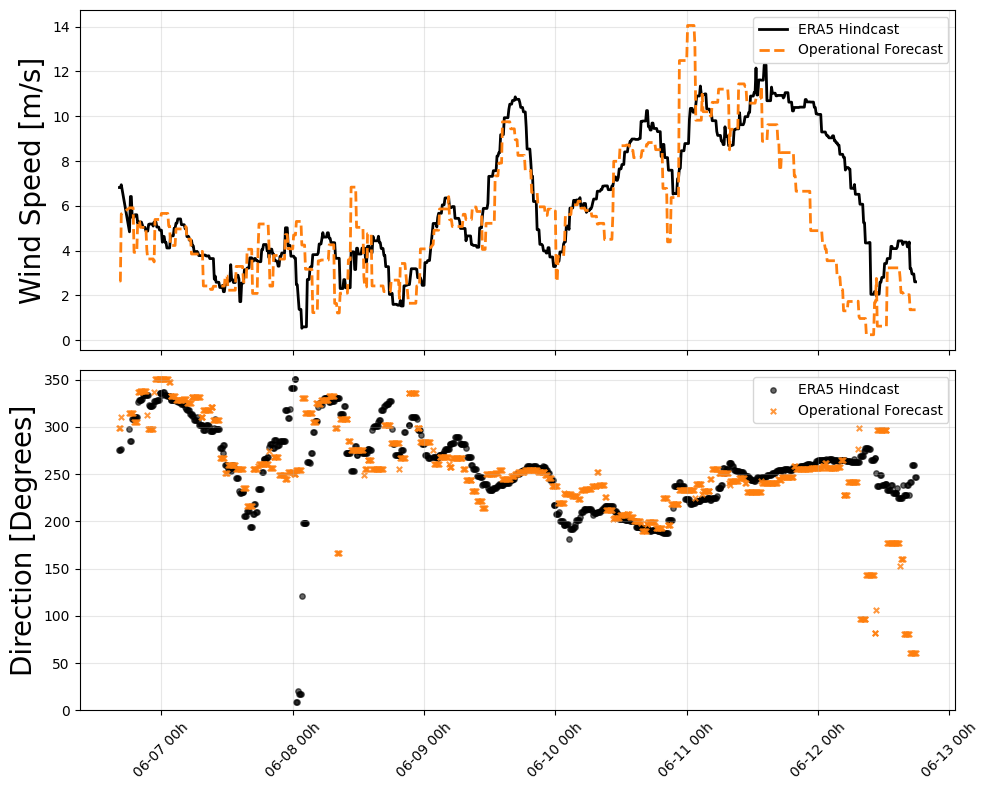

In [19]:
plot_hindcast_comparison(df)

In [20]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_wave_comparison(df):
    """
    Plots Forecast vs Hindcast for SIGNIFICANT WAVE HEIGHT (SWH).
    Now explicitly uses interpolated hindcast columns.
    """
    # 1. SETUP PLOT
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))
    
    trip_id = df["trip_no"].iloc[0] if "trip_no" in df.columns else "Unknown"
    #fig.suptitle(f'Voyage {trip_id}: Wave Forecast vs ERA5 Hindcast', fontsize=16)

    # 2. IDENTIFY COLUMNS
    # Your previous interpolation saved it as 'swh_hindcast'
    hc_col = 'swh_hindcast' 
    fc_col = 'swh_forecast'

    # 3. PLOT HINDCAST (Actuals)
    if hc_col in df.columns:
        ax1.plot(df.index, df[hc_col], label='ERA5 Hindcast', color='black', linewidth=2.5, zorder=2)
    
    else:
        print(f"Warning: {hc_col} not found in DataFrame.")

    # 4. PLOT FORECAST
    if fc_col in df.columns:
        ax1.plot(df.index, df[fc_col], label='Operational Forecast', color='#1f77b4', linestyle='--', linewidth=2, zorder=3)
    
    # Aesthetics
    ax1.set_ylabel('Wave Height [m]', fontsize=20)
    #ax1.set_title("Significant Wave Height Comparison", fontsize=14)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # Format Time Axis
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %Hh'))
    ax1.set_ylim([0,3])
    plt.xticks(rotation=0)
    plt.xlabel("Date / Time", fontsize=14)

    plt.tight_layout()
    plt.show()

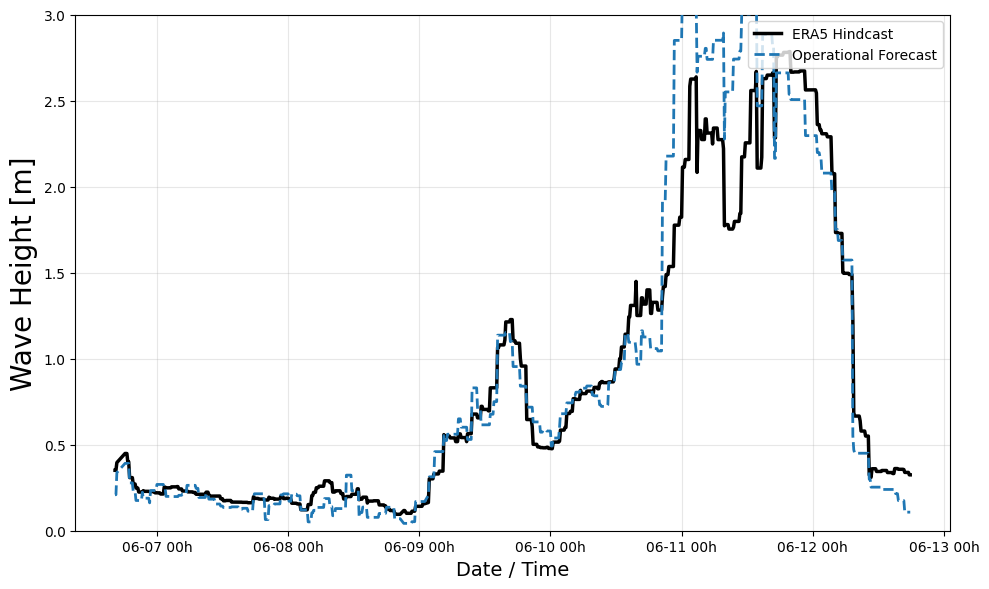

In [21]:
plot_wave_comparison(df)

In [22]:
def plot_rolling_wave_comparison(df, n_trip):
    # Setup 2-panel plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    root_dir = f"trip_{n_trip}_rolling"
    
    # --- AUTOMATIC COLOR HANDLING (VIVID TURBO) ---
    num_days = 0
    while os.path.exists(f"{root_dir}/day_{num_days + 1}"):
        num_days += 1
    
    colors = [cm.turbo(i) for i in np.linspace(0, 0.9, num_days)] if num_days > 0 else []

    # --- 1. PLOT HINDCAST (Ground Truth) ---
    if 'swh_hindcast' in df.columns:
        ax1.plot(df.index, df['swh_hindcast'], label='ERA5 Hindcast', 
                 color='black', linewidth=2.5, zorder=10)
        
    if 'wave_dir_hindcast' in df.columns:
        ax2.plot(df.index, df['wave_dir_hindcast'], label='ERA5 Hindcast', 
                 color='black', linewidth=2.5, zorder=10)

    # --- 2. PLOT ROLLING FORECASTS ---
    day_idx = 1
    while os.path.exists(f"{root_dir}/day_{day_idx}"):
        wave_path = f"{root_dir}/day_{day_idx}/wave_update.grib"
        wind_path = f"{root_dir}/day_{day_idx}/wind_update.grib"
        
        if os.path.exists(wave_path):
            temp_df = df.copy()
            # This uses your updated interpolation logic that includes mwd_forecast
            temp_df = interpolate_forecast(temp_df, wave_path, wind_path)
            
            with xr.open_dataset(wave_path, engine='cfgrib') as ds:
                model_run_start = pd.to_datetime(ds.time.values).tz_localize('UTC')
            
            plot_df = temp_df[temp_df.index >= model_run_start].copy()
            color = colors[day_idx - 1]
            
            # Panel 1: Wave Height (SWH)
            ax1.plot(plot_df.index, plot_df['swh_forecast'], 
                     label=f'Forecast Day {day_idx}', color=color, 
                     linestyle=':', linewidth=2.5, zorder=2)
            
            # Panel 2: Wave Direction (MWD)
            if 'mwd_forecast' in plot_df.columns:
                ax2.scatter(plot_df.index, plot_df['mwd_forecast'], 
                            color=color, s=20, marker='x', alpha=0.8, zorder=2)
        
        day_idx += 1

    # --- AESTHETICS (Matching Wind Plot) ---
    route_id = fetch_route(n_trip)
    fig.suptitle(f"Wave Evolution - Route {route_id}", fontsize=22, y=0.98)

    # Panel 1 Config (SWH)
    ax1.set_ylabel('SWH [m]', fontsize=20)
    ax1.grid(True, alpha=0.4, linestyle='--')
    ax1.tick_params(labelsize=14)
    if not df.empty and 'swh_hindcast' in df.columns:
        ax1.set_ylim([0, df['swh_hindcast'].max() * 1.3])

    # Panel 2 Config (Direction)
    ax2.set_ylabel('Direction [Degrees]', fontsize=20)
    ax2.set_ylim(0, 360)
    ax2.set_yticks([0, 90, 180, 270, 360])
    ax2.set_yticklabels(['0', '90', '180', '270', '360'])
    ax2.grid(True, alpha=0.4, linestyle='--')
    ax2.tick_params(labelsize=14)

    # Global Time Axis Config
    ax2.xaxis.set_major_locator(mdates.HourLocator(interval=12))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
    
    # Legend at the bottom
    handles, labels = ax1.get_legend_handles_labels()
    ax2.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.25), 
                frameon=True, ncol=4, fontsize=14, edgecolor='black')

    plt.tight_layout(rect=[0, 0.08, 1, 0.96])
    plt.show()

In [23]:
import matplotlib.cm as cm
import numpy as np

--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---


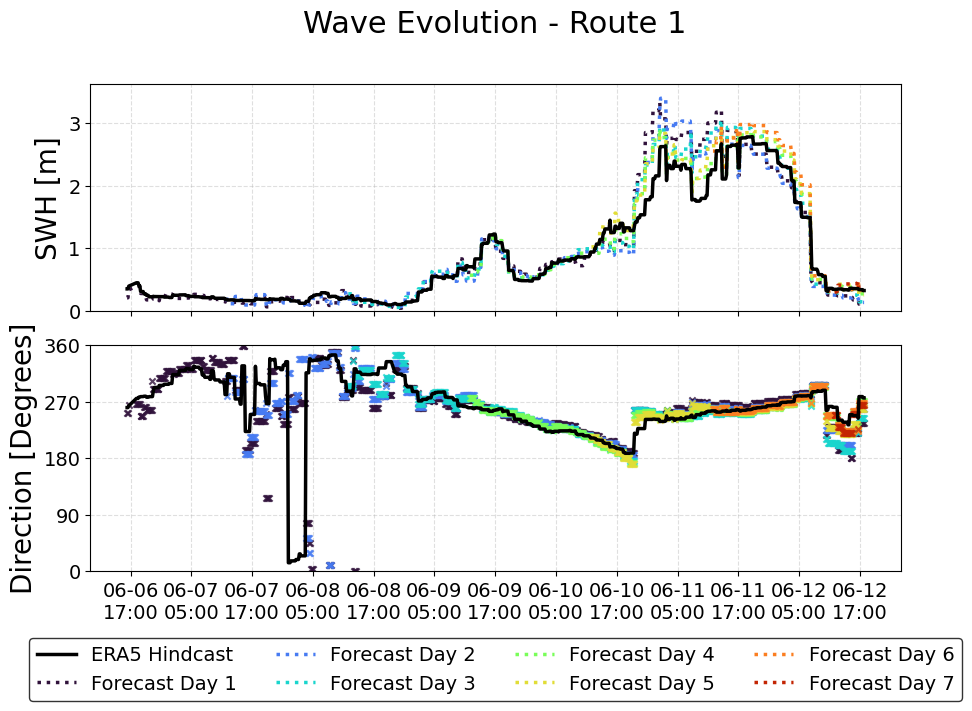

In [24]:
plot_rolling_wave_comparison(df, n_trip)

In [25]:
def plot_rolling_wind_comparison(df, n_trip):
    # Setup 2-panel plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    root_dir = f"trip_{n_trip}_rolling"
    
    # --- AUTOMATIC COLOR HANDLING (VIVID) ---
    num_days = 0
    while os.path.exists(f"{root_dir}/day_{num_days + 1}"):
        num_days += 1
    
    # 'turbo' is highly vivid and easier to distinguish than viridis
    colors = [cm.turbo(i) for i in np.linspace(0, 0.9, num_days)] if num_days > 0 else []

    # --- 1. PLOT HINDCAST (Ground Truth) ---
    if 'wind_speed_hindcast' in df.columns:
        ax1.plot(df.index, df['wind_speed_hindcast'], label='ERA5 Hindcast', 
                 color='black', linewidth=2.5, zorder=10)
        
    if 'windU_hindcast' in df.columns and 'windV_hindcast' in df.columns:
        df['wind_dir_hindcast'] = (270 - np.degrees(np.arctan2(df['windV_hindcast'], df['windU_hindcast']))) % 360
        ax2.plot(df.index, df['wind_dir_hindcast'], label='ERA5 Hindcast', 
                    color='black', linewidth=2.5, zorder=10)

    # --- 2. PLOT ROLLING FORECASTS ---
    day_idx = 1
    while os.path.exists(f"{root_dir}/day_{day_idx}"):
        wave_path = f"{root_dir}/day_{day_idx}/wave_update.grib"
        wind_path = f"{root_dir}/day_{day_idx}/wind_update.grib"
        
        if os.path.exists(wind_path):
            temp_df = df.copy()
            temp_df = interpolate_forecast(temp_df, wave_path, wind_path)
            
            with xr.open_dataset(wind_path, engine='cfgrib') as ds:
                model_run_start = pd.to_datetime(ds.time.values).tz_localize('UTC')
            
            plot_df = temp_df[temp_df.index >= model_run_start].copy()
            plot_df['wind_dir_forecast'] = (270 - np.degrees(np.arctan2(plot_df['windV_forecast'], plot_df['windU_forecast']))) % 360
            
            color = colors[day_idx - 1]
            
            # Panel 1: Wind Speed
            ax1.plot(plot_df.index, plot_df['wind_speed_forecast'], 
                     label=f'Forecast Day {day_idx}', color=color, 
                     linestyle=':', linewidth=2.5, zorder=2)
            
            # Panel 2: Wind Direction (Numerical)
            ax2.scatter(plot_df.index, plot_df['wind_dir_forecast'], 
                        color=color, s=20, marker='x', alpha=0.8, zorder=2)
        
        day_idx += 1

    # --- AESTHETICS ---
    route_id = fetch_route(n_trip)
    fig.suptitle(f"Wind Evolution - Route {route_id}", fontsize=22, y=0.98)

    # Panel 1 Config
    ax1.set_ylabel('Wind Speed [m/s]', fontsize=20)
    ax1.grid(True, alpha=0.4, linestyle='--')
    ax1.tick_params(labelsize=14)

    # Panel 2 Config (Numerical Degrees)
    ax2.set_ylabel('Direction [Degrees]', fontsize=20)
    ax2.set_ylim(0, 360)
    ax2.set_yticks([0, 90, 180, 270, 360])
    # Reverted to numerical labels
    ax2.set_yticklabels(['0', '90', '180', '270', '360'])
    ax2.grid(True, alpha=0.4, linestyle='--')
    ax2.tick_params(labelsize=14)

    # Global Time Axis Config
    ax2.xaxis.set_major_locator(mdates.HourLocator(interval=12))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
    
    # Legend at the bottom
    handles, labels = ax1.get_legend_handles_labels()
    ax2.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.25), 
                frameon=True, ncol=4, fontsize=14, edgecolor='black')

    plt.tight_layout(rect=[0, 0.08, 1, 0.96])
    plt.show()

--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---


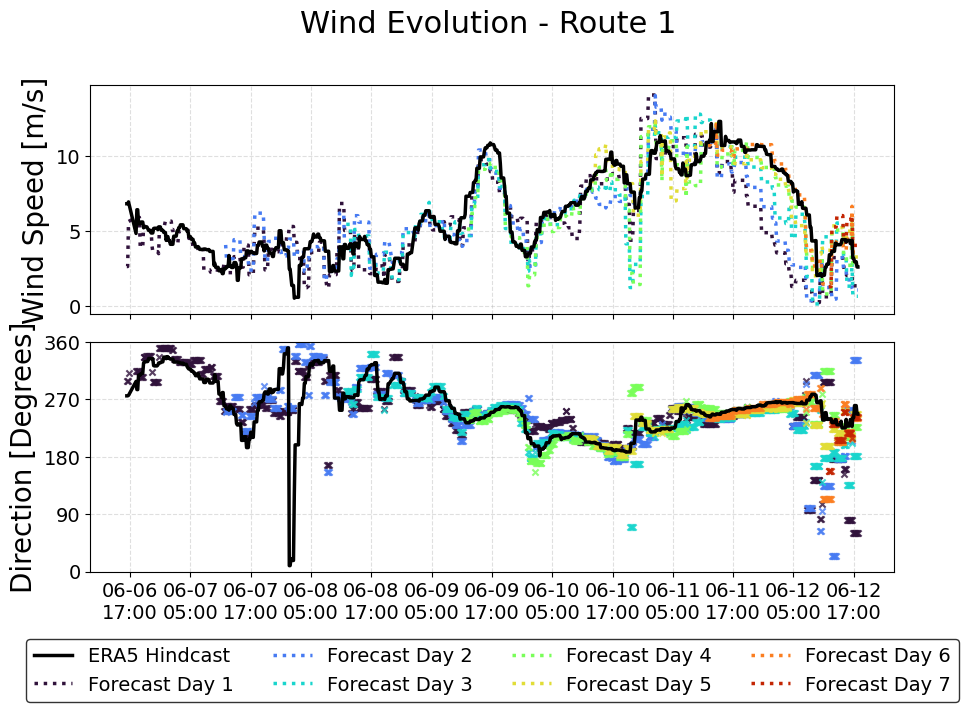

In [26]:
plot_rolling_wind_comparison(df, n_trip)

In [ ]:
def wind_speed_forecast_comparison(df, n_trip):
    # Increase figure size to handle larger fonts comfortably
    fig, ax1 = plt.subplots(figsize=(18, 11)) 
    root_dir = f"trip_{n_trip}_rolling"
    data_start = df.index.min()
    
    # Define font sizes for high visibility
    label_size = 32
    tick_size = 24
    legend_size = 22
    
    num_days = 0
    while os.path.exists(f"{root_dir}/day_{num_days + 1}"):
        num_days += 1
    colors = [cm.turbo_r(i) for i in np.linspace(0, 0.9, num_days)] if num_days > 0 else []

    # Plotting using hindcast data
    if 'wind_speed_hindcast' in df.columns:
        ax1.plot(df.index, df['wind_speed_hindcast'], label='ERA5 Hindcast', 
                 color='black', linewidth=4, zorder=10)

    # Plotting using forecast data
    day_idx = 1
    while os.path.exists(f"{root_dir}/day_{day_idx}"):
        wave_path = f"{root_dir}/day_{day_idx}/wave_update.grib"
        wind_path = f"{root_dir}/day_{day_idx}/wind_update.grib"
        
        if os.path.exists(wind_path):
            temp_df = df.copy()
            # Assuming interpolate_forecast is defined elsewhere
            temp_df = interpolate_forecast(temp_df, wave_path, wind_path)
            
            with xr.open_dataset(wind_path, engine='cfgrib') as ds:
                model_run_start = pd.to_datetime(ds.time.values).tz_localize('UTC')
            
            plot_df = temp_df[temp_df.index >= model_run_start].copy()
            color = colors[day_idx - 1]
            
            ax1.plot(plot_df.index, plot_df['wind_speed_forecast'], 
                     label=f'Forecast Day {day_idx}', color=color, 
                     linestyle='-', marker='s', markersize=8, 
                     linewidth=2.5, alpha=0.9, zorder=5)
        day_idx += 1

    # Vertical Lines for 12:00
    potential_dates = pd.date_range(start=data_start.floor('D') + pd.Timedelta(hours=12), 
                                    end=df.index.max().ceil('D'), 
                                    freq='24h')
    valid_vlines = [dt for dt in potential_dates if dt >= data_start]
    for dt in valid_vlines:
        ax1.axvline(dt, color='gray', linestyle='--', linewidth=2, alpha=0.6, zorder=1)

    # Axis Formatting
    ax1.set_ylabel('$V_{wind}$ [m/s]', fontsize=label_size, labelpad=15)
    ax1.set_xlim(data_start, df.index.max())
    ax1.grid(True, which='major', axis='y', alpha=0.4, linestyle=':')
    
    # Tick customisation
    ax1.tick_params(axis='both', labelsize=tick_size, length=8, width=2)
    ax1.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12]))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
    
    # Legend: Expanded to use the maximum horizontal space available
    # bbox_to_anchor uses (x, y, width, height)
    ax1.legend(loc='upper center', 
               bbox_to_anchor=(0.0, -0.22, 1.0, 0.1), 
               mode="expand", 
               ncol=4, 
               frameon=True, 
               fontsize=legend_size, 
               edgecolor='black',
               borderaxespad=0.)

    # Adjust layout to make room for the large legend and labels
    plt.subplots_adjust(bottom=0.25, left=0.1, right=0.95, top=0.95)
    plt.show()

--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---


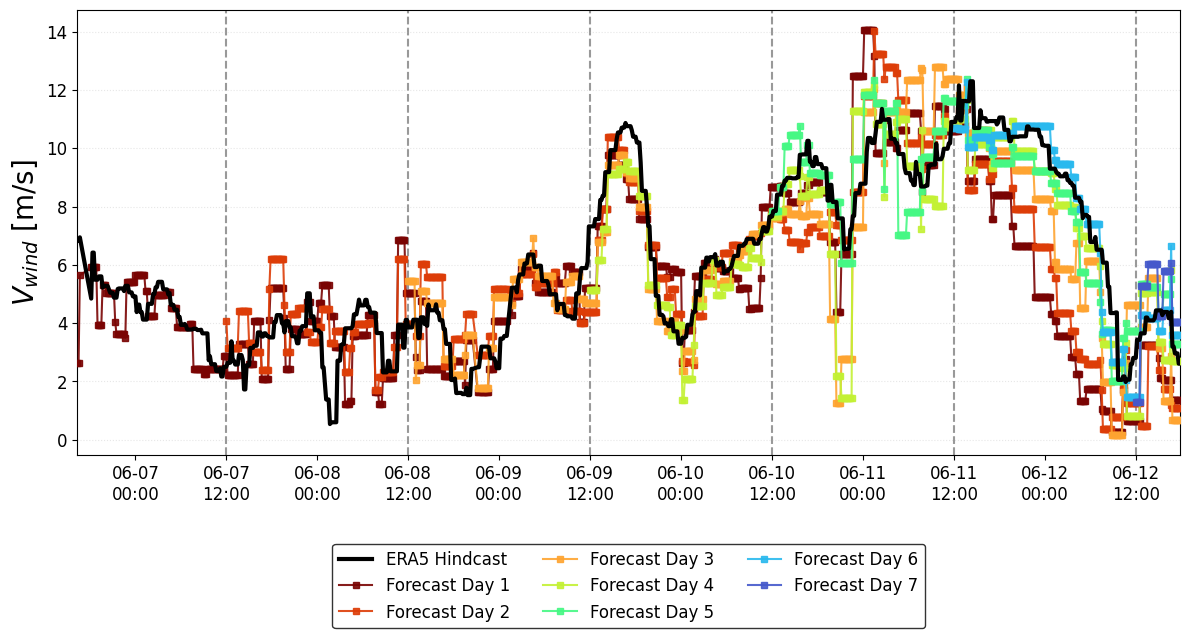

In [ ]:
wind_speed_forecast_comparison(df, n_trip)

In [29]:
def wave_height_forecast_comparison(df, n_trip):
    fig, ax1 = plt.subplots(figsize=(12, 7))
    root_dir = f"trip_{n_trip}_rolling"
    data_start = df.index.min()
    
    num_days = 0
    while os.path.exists(f"{root_dir}/day_{num_days + 1}"):
        num_days += 1
    colors = [cm.turbo_r(i) for i in np.linspace(0, 0.9, num_days)] if num_days > 0 else []

    if 'swh_hindcast' in df.columns:
        ax1.plot(df.index, df['swh_hindcast'], label='ERA5 Hindcast', 
                 color='black', linewidth=3, zorder=10)

    day_idx = 1
    while os.path.exists(f"{root_dir}/day_{day_idx}"):
        wave_path = f"{root_dir}/day_{day_idx}/wave_update.grib"
        wind_path = f"{root_dir}/day_{day_idx}/wind_update.grib"
        
        if os.path.exists(wave_path):
            temp_df = df.copy()
            temp_df = interpolate_forecast(temp_df, wave_path, wind_path)
            
            with xr.open_dataset(wave_path, engine='cfgrib') as ds:
                model_run_start = pd.to_datetime(ds.time.values).tz_localize('UTC')
            
            plot_df = temp_df[temp_df.index >= model_run_start].copy()
            color = colors[day_idx - 1]
            
            ax1.plot(plot_df.index, plot_df['swh_forecast'], 
                     label=f'Forecast Day {day_idx}', color=color, 
                     linestyle='-', marker='s', markersize=4, 
                     linewidth=1.5, alpha=0.9, zorder=5)
        day_idx += 1

    # --- UPDATED VERTICAL LINES: Gray, Dashed, 12:00 only ---
    potential_dates = pd.date_range(start=data_start.floor('D') + pd.Timedelta(hours=12), 
                                    end=df.index.max().ceil('D'), 
                                    freq='24h')
    
    valid_vlines = [dt for dt in potential_dates if dt >= data_start]
    
    for dt in valid_vlines:
        ax1.axvline(dt, color='gray', linestyle='--', linewidth=1.5, alpha=0.8, zorder=1)

    ax1.set_ylabel('$H_s$ [m]', fontsize=20)
    ax1.set_xlim(data_start, df.index.max())
    if not df.empty and 'swh_hindcast' in df.columns:
        ax1.set_ylim([0, max(df['swh_hindcast'].max(), 
                             df['swh_forecast'].max() if 'swh_forecast' in df.columns else 0) * 1.2])

    ax1.grid(True, which='major', axis='y', alpha=0.3, linestyle=':')
    ax1.tick_params(labelsize=12)
    ax1.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12]))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
    ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), 
               frameon=True, fontsize=12, ncol=3, edgecolor='black')
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---
--- Smart Interpolation (Nearest + Coastal Patch) ---


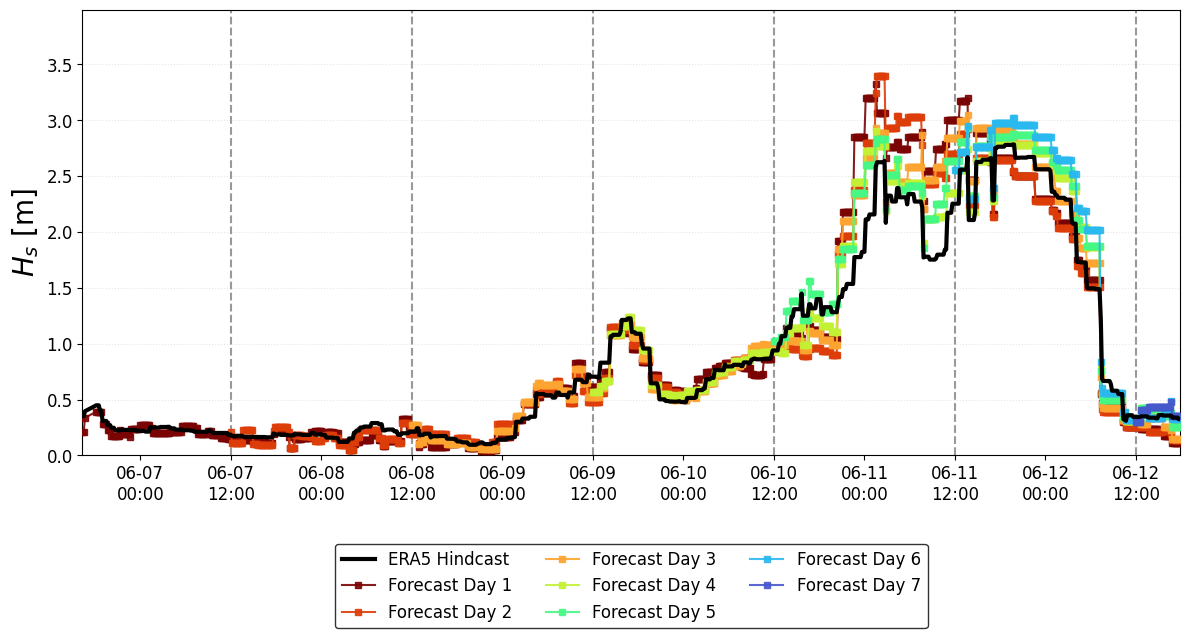

In [30]:
wave_height_forecast_comparison(df, n_trip)

In [31]:
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

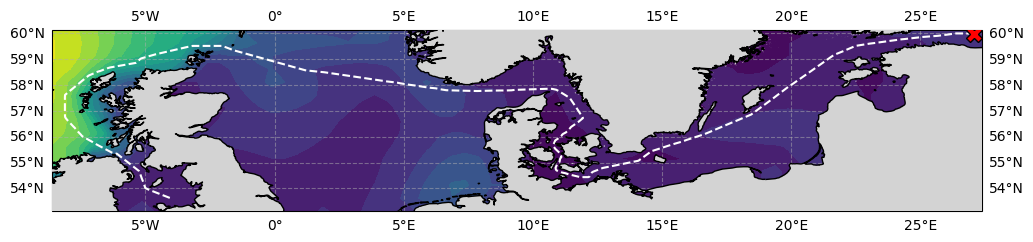

In [32]:
idx = 0
target_time_raw = df.index[idx]
ship_lon = df.lon.values[idx]
ship_lat = df.lat.values[idx]
lati_w = ds.latitude.values if 'latitude' in ds.coords else ds.lat.values
longi_w = ds.longitude.values if 'longitude' in ds.coords else ds.lon.values

target_time = pd.Timestamp(target_time_raw).tz_localize(None)

swh_dims = ds['swh'].dims
time_dim = [d for d in swh_dims if 'time' in d or d == 'step'][0]
swh_slice = ds['swh'].sel({time_dim: target_time}, method='nearest')

actual_time_found = swh_slice[time_dim].values

plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
ax.add_feature(cfeature.COASTLINE, zorder=4)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

im = ax.contourf(longi_w, lati_w, swh_slice, 
                 levels=20, cmap='viridis', transform=ccrs.PlateCarree())

ax.plot(df.lon, df.lat, color='white', 
        linewidth=1.5, linestyle='--', transform=ccrs.PlateCarree(), label='Voyage Path')

ax.plot(ship_lon, ship_lat, color='red', marker='X', markersize=12, 
        markeredgecolor='black', transform=ccrs.PlateCarree(), 
        label=f'Ship at Index {idx}', zorder=5)



plt.show()

Successfully loaded Forecast Day 1 waves using: {'dataType': 'fc'}


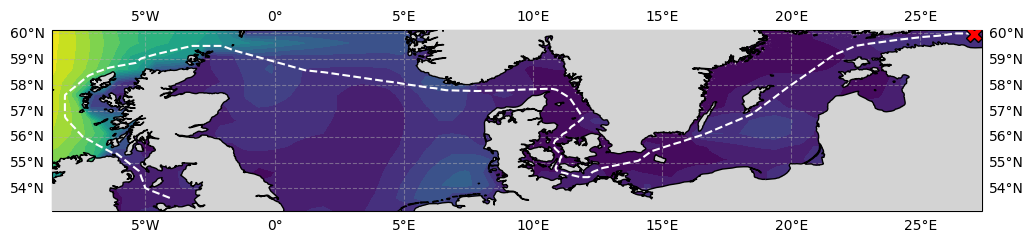

In [33]:
path_fc = f"trip_{n_trip}_rolling/day_1/wave_update.grib"
ds_fc = None
fc_filters = [{'typeOfLevel': 'surface'}, {'dataType': 'fc'}, {'stepType': 'instant'}]

for wf in fc_filters:
    try:
        temp = xr.open_dataset(path_fc, engine='cfgrib', filter_by_keys=wf, backend_kwargs={'indexpath': ''})
        if 'swh' in temp:
            ds_fc = temp
            print(f"Successfully loaded Forecast Day 1 waves using: {wf}")
            break
    except: continue

if ds_fc is not None:
    # Standardize dimensions for time selection
    if 'step' in ds_fc.dims:
        ds_fc = ds_fc.swap_dims({'step': 'valid_time'})
    # Coastal safety patch
    ds_fc = ds_fc.ffill(dim='longitude', limit=2).bfill(dim='longitude', limit=2)
    ds_fc = ds_fc.ffill(dim='latitude', limit=2).bfill(dim='latitude', limit=2)

# --- 3. VERIFICATION PLOT (Choose ds_hc or ds_fc to check) ---
# Switch 'ds' to 'ds_fc' if you want to verify the forecast heatmap instead
ds = ds_fc

idx = 0
target_time_raw = df.index[idx]
ship_lon = df.lon.values[idx]
ship_lat = df.lat.values[idx]

# Extract coordinates from dataset for the grid
lati_w = ds.latitude.values if 'latitude' in ds.coords else ds.lat.values
longi_w = ds.longitude.values if 'longitude' in ds.coords else ds.lon.values

# Ensure target time is timezone-naive to match GRIB
target_time = pd.Timestamp(target_time_raw).tz_localize(None)

# Find time dimension name and slice data
swh_dims = ds['swh'].dims
time_dim = [d for d in swh_dims if 'time' in d or d == 'step' or d == 'valid_time'][0]
swh_slice = ds['swh'].sel({time_dim: target_time}, method='nearest')

actual_time_found = swh_slice[time_dim].values

# Figure setup
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
ax.add_feature(cfeature.COASTLINE, zorder=4)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

# Plot Heatmap
im = ax.contourf(longi_w, lati_w, swh_slice, levels=20, cmap='viridis', transform=ccrs.PlateCarree())

# Plot Voyage Path
ax.plot(df.lon, df.lat, color='white', linewidth=1.5, linestyle='--', 
        transform=ccrs.PlateCarree(), label='Voyage Path')

# Plot Ship Position at Index
ax.plot(ship_lon, ship_lat, color='red', marker='X', markersize=12, 
        markeredgecolor='black', transform=ccrs.PlateCarree(), 
        label=f'Ship at Index {idx}', zorder=5)
plt.show()

In [ ]:
)))

SyntaxError: unmatched ')' (1184572320.py, line 1)

: 

In [ ]:
def calculate_relative_angle(target_angle, ship_heading):
    """
    Computes the shortest angular difference between a target (wind/wave/current)
    and the ship's heading. Result is between 0 and 180.
    0 = Head, 90 = Beam, 180 = Following.
    """
    diff = np.abs(target_angle - ship_heading) % 360
    relative_angle = np.where(diff > 180, 360 - diff, diff)
    return relative_angle

In [ ]:
def finalize_hindcast_features(df):
    """
    Derives the relative 'head' angles for XGBoost training.
    Assumes 'cog' is your ship's Course Over Ground column.
    """
    
    # --- 1. Wind Direction (Coming From) ---
    # atan2(u,v) gives direction 'to'. Adding 180 flips it to 'coming from'.
    wind_math = np.degrees(np.arctan2(df['windU_hindcast'], df['windV_hindcast']))
    df['wind_dir_hindcast_abs'] = (wind_math + 180) % 360
    
    # Create the feature: wind_dir_hindcast_head
    df['wind_dir_hindcast_head'] = calculate_relative_angle(df['wind_dir_hindcast_abs'], df['heading'])

    # --- 2. Wave Direction (Coming From) ---
    # wave_dir_hindcast (MWD) is already 'coming from' in ERA5
    # Create the feature: wave_dir_hindcast_head
    df['wave_dir_hindcast_head'] = calculate_relative_angle(df['wave_dir_hindcast'], df['heading'])

    return df

# Apply to both datasets
df1_final = finalize_hindcast_features(df1_final)
df2_final = finalize_hindcast_features(df2_final)

In [ ]:
path_train_new = '..\\Data\\Data used for model Training (Corrected).csv'
path_val_new = '..\\Data\\Data used for model Validation (Corrected).csv'

# Save to CSV
df1_final.to_csv(path_train_new)
df2_final.to_csv(path_val_new)